**Activity:** Compare RF vs XGBoost on a local dataset, then build a dashboard (UI + backend)

## The problem

For a given **district** of Sri Lanka, predict the **rain level of the next dekad** (next 10 days):

| Class | Rule |
|---|---|
| **Dry** | 10-day rainfall below 10 mm (less than about 1 mm per day) |
| **Moderate** | 10 mm to below 100 mm |
| **Heavy** | 100 mm or more (about 10 mm or more per day) |


## Steps in this notebook

1. **Collect data**: load and clean the dataset
2. **Apply RF and XGBoost**: tune the parameters (not default values) and train
3. **Compare performance**: same test data, same metrics
4. **Inference**: save the models as pickle files and test a prediction

## 0. Import libraries
`features.py` is our own file. It has code shared by this notebook **and** the app,
so features are calculated the same way in training and in prediction.

In [1]:
import pickle, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

from features import (DISTRICTS, DISTRICT_TO_NUM, CLASS_NAMES, FEATURES,
                      rain_class, dekad_of_year, build_feature_row)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

## 1. Collect data

**Source:** Humanitarian Data Exchange (HDX), *Sri Lanka: Rainfall Indicators at Subnational Level*
(https://data.humdata.org/dataset/lka-rainfall-subnational).
The values come from CHIRPS satellite rainfall data with station data, averaged for each
administrative area. There is **one row every dekad** (10 days) for each area.

In [2]:
raw = pd.read_excel("data/lka-rainfall-subnat-full.xlsx")
print("Shape:", raw.shape)
raw.head()

Shape: (55076, 15)


,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version
0,36526,2,25830,LK22,67,130.552250,71.977610,313.70150,290.53680,925.70150,967.18805,176.09310,107.83818,95.73266,final
1,36536,2,25830,LK22,67,158.716420,56.896020,355.71643,231.92786,968.17914,920.60800,264.50232,152.24738,105.13945,final
2,36546,2,25830,LK22,67,34.567165,54.214924,323.83585,183.08856,897.23880,856.45180,66.81959,174.83032,104.73468,final
3,36557,2,25830,LK22,67,112.567160,44.043285,305.85074,155.15424,911.76117,787.20544,239.72122,194.09460,115.72266,final
4,36567,2,25830,LK22,67,52.417910,30.813930,199.55223,129.07214,845.98505,705.95220,160.32285,152.56879,119.69652,final


### 1.1 Understand the columns
- `date` is stored as an **Excel day number** (e.g. 36526 = 2000-01-01). We convert it to a real date.
- `adm_level` 1 = **province** (9), 2 = **district** (25).
- `version`: `final` = checked value, `prelim` = early, temporary value.

In [3]:
raw["date"] = pd.to_datetime(raw["date"], unit="D", origin="1899-12-30")
print("Date range:", raw["date"].min().date(), "to", raw["date"].max().date())
print("\nRows per adm_level:\n", raw["adm_level"].value_counts())
print("\nRows per version:\n", raw["version"].value_counts())
print("\nMissing values:\n", raw.isna().sum()[raw.isna().sum() > 0])

Date range: 1981-01-01 to 2026-07-11

Rows per adm_level:
 adm_level
2    40316
1    14760
Name: count, dtype: int64

Rows per version:
 version
final     55008
prelim       68
Name: count, dtype: int64

Missing values:
 r1h         66
r1h_avg     66
r3h        264
r3h_avg    264
r1q         66
r3q        264
dtype: int64


### 1.2 Clean the data
- Keep **districts only** (`adm_level == 2`). Province rows are bigger areas made from the same data, so they repeat information.
- Keep **final** values only. The `prelim` values may change later.
- The missing values are only in the **first dekads of 1981**: a 1-month or 3-month total cannot be calculated at the very start. They are removed later, after we create lag features.

In [4]:
df = raw[(raw["adm_level"] == 2) & (raw["version"] == "final")].copy()
df = df.sort_values(["PCODE", "date"]).reset_index(drop=True)
df["district"] = df["PCODE"].map(DISTRICTS)
print("Rows after cleaning:", len(df), "| districts:", df["PCODE"].nunique())

# Check: are there missing dekads inside any district? (largest gap should be 11 days)
print("Largest gap between rows (days):", df.groupby("PCODE")["date"].diff().dt.days.max())

Rows after cleaning: 40266 | districts: 25
Largest gap between rows (days): 11.0


### 1.3 Check how the indicator columns are calculated
This step is important to find **data leakage**. If a column is calculated from the
value we want to predict, we must not use it (from the same row) as a feature.

In [5]:
g = df.groupby("PCODE")["rfh"]
sum3 = g.rolling(3).sum().reset_index(level=0, drop=True)
sum9 = g.rolling(9).sum().reset_index(level=0, drop=True)
print("r1h = sum of last 3 dekads?  max difference:", (df["r1h"] - sum3).abs().max())
print("r3h = sum of last 9 dekads?  max difference:", (df["r3h"] - sum9).abs().max())
print("rfq = (rfh+5)/(rfh_avg+5)*100?  max difference:",
      (df["rfq"] - (df["rfh"] + 5) / (df["rfh_avg"] + 5) * 100).abs().max())

df["dekad_of_year"] = dekad_of_year(df["date"])
print("Is rfh_avg fixed for each district + dekad?",
      df.groupby(["PCODE", "dekad_of_year"])["rfh_avg"].nunique().max() == 1)

r1h = sum of last 3 dekads?  max difference: 0.00010000000020227162
r3h = sum of last 9 dekads?  max difference: 0.00026000000002568413
rfq = (rfh+5)/(rfh_avg+5)*100?  max difference: 0.00010031553131284454
Is rfh_avg fixed for each district + dekad? True


**Result:** `r1h`, `r3h`, `rfq`, `r1q`, `r3q` in a row all **include that row's `rfh`**.
So using them from the **same row** would leak the answer. We will only use their values
from the **previous dekad** (t-1). The long-term averages (`rfh_avg` etc.) are fixed for each
district and dekad, so they are known in advance and are safe to use.

### 1.4 A quick look: rainfall pattern over the year
The two monsoons (South-West: May–Sep, North-East: Dec–Feb) and the inter-monsoon rains
(Mar–Apr, Oct–Nov) give each district a different pattern. This is why
**district** and **time of year** are useful features.

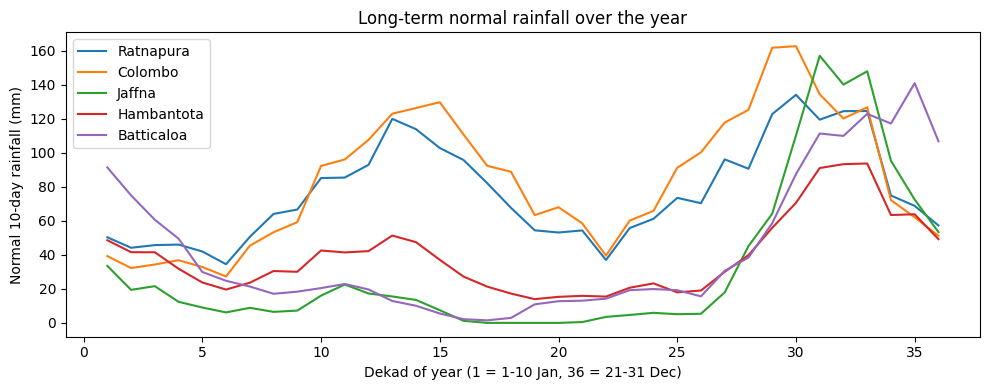

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
for code_ in ["LK91", "LK11", "LK41", "LK33", "LK51"]:
    s = df[df["PCODE"] == code_].groupby("dekad_of_year")["rfh_avg"].first()
    ax.plot(s.index, s.values, label=DISTRICTS[code_])
ax.set_xlabel("Dekad of year (1 = 1-10 Jan, 36 = 21-31 Dec)")
ax.set_ylabel("Normal 10-day rainfall (mm)")
ax.set_title("Long-term normal rainfall over the year")
ax.legend(); plt.tight_layout(); plt.show()

## 2. Prepare features and label

### 2.1 Label
The label is the **rain class of the dekad itself** (`rfh` → Dry / Moderate / Heavy).

### 2.2 Features (only past or fixed information)
| Feature | Meaning |
|---|---|
| `district_num` | District as a number (0–24) |
| `dekad_of_year` | 1–36, time of year (captures monsoons) |
| `rfh_avg` | Long-term normal rainfall for this district and dekad |
| `lag1`, `lag2`, `lag3` | Rainfall of the last 1, 2, 3 dekads |
| `r1h_lag1`, `r3h_lag1` | Total rainfall of the last 1 month / 3 months |
| `rfq_lag1`, `r1q_lag1`, `r3q_lag1` | How wet the last dekad / month / 3 months were compared to normal (%) |

We use `groupby("PCODE").shift(k)` so each district is shifted **separately**.

In [7]:
df["district_num"] = df["PCODE"].map(DISTRICT_TO_NUM)
g = df.groupby("PCODE")
for k in [1, 2, 3]:
    df[f"lag{k}"] = g["rfh"].shift(k)
for col in ["r1h", "r3h", "rfq", "r1q", "r3q"]:
    df[f"{col}_lag1"] = g[col].shift(1)

df["label"] = rain_class(df["rfh"])

# Remove rows where past values do not exist (start of each district's history)
data = df.dropna(subset=FEATURES).copy()
data = data.sort_values(["date", "PCODE"]).reset_index(drop=True)   # time order
print("Rows ready for ML:", len(data))
data[["date", "district", "rfh", "label"] + FEATURES].head()

Rows ready for ML: 40047


,date,district,rfh,label,district_num,dekad_of_year,rfh_avg,lag1,lag2,lag3,r1h_lag1,r3h_lag1,rfq_lag1,r1q_lag1,r3q_lag1
0,1981-04-01,Colombo,72.608696,1,0,10,92.236230,61.217392,14.652174,21.695652,97.565216,242.56523,103.165640,63.002430,67.72874
1,1981-04-01,Gampaha,55.021280,1,1,10,82.567375,57.425533,10.829787,10.808511,79.063830,198.48936,109.515750,58.258583,64.62017
2,1981-04-01,Kalutara,98.692310,1,2,10,98.197430,75.942310,19.576923,39.961540,135.480770,317.71155,114.170230,76.515915,74.03970
3,1981-04-01,Kandy,38.316666,1,3,10,66.821670,58.783333,9.183333,9.233334,77.200000,271.61667,113.997200,60.378284,65.24260
4,1981-04-01,Nuwara Eliya,62.224136,1,5,10,72.696550,62.586210,19.034483,23.551723,105.172410,278.98276,111.870026,75.291916,72.59528


label
Moderate    58.3 %
Dry         23.8 %
Heavy       17.9 %
Name: count, dtype: str


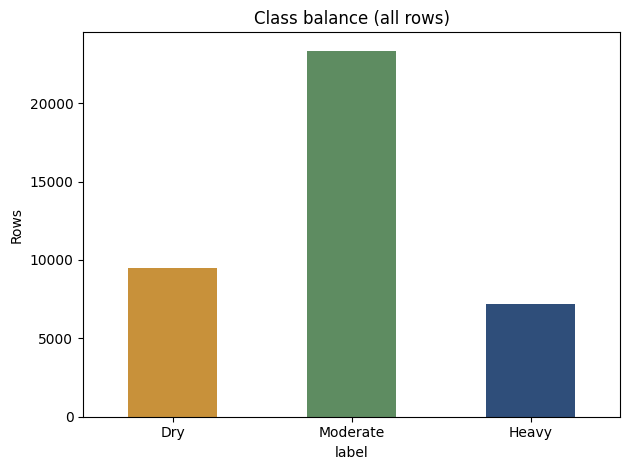

In [8]:
counts = pd.Series(data["label"]).map(dict(enumerate(CLASS_NAMES))).value_counts()
print((counts / counts.sum() * 100).round(1).astype(str) + " %")
counts.reindex(CLASS_NAMES).plot(kind="bar", color=["#C8913A", "#5E8C61", "#2F4E7A"],
                                  title="Class balance (all rows)")
plt.ylabel("Rows"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

The classes are **not balanced** ("Moderate" is the largest). So:
- we use **macro F1** (average F1 of the three classes, each class counts equally) as the main metric;
- we use **class weights** so the models pay attention to Dry and Heavy too.

### 2.3 Time-based train / test split
Weather data is a **time series**. A random split would put future rows in training,
which is a form of leakage. So we split by time:
- **Train:** 1981 – 2018
- **Test:** 2019 – 2026 (never seen during training or tuning)

In [9]:
train = data[data["date"] < "2019-01-01"]
test = data[data["date"] >= "2019-01-01"]
X_train, y_train = train[FEATURES], train["label"].values
X_test, y_test = test[FEATURES], test["label"].values
print("Train rows:", len(train), train["date"].min().date(), "to", train["date"].max().date())
print("Test rows: ", len(test), test["date"].min().date(), "to", test["date"].max().date())

Train rows: 33297 1981-04-01 to 2018-12-21
Test rows:  6750 2019-01-01 to 2026-06-21


### 2.4 Baselines (simple rules, no ML)
A model is only useful if it beats simple rules:
- **Majority class:** always predict "Moderate".
- **Normal rainfall rule:** predict the class of the long-term normal (`rfh_avg`).

In [10]:
def scores(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro"),
    }

baseline_majority = np.ones_like(y_test)
baseline_normal = rain_class(test["rfh_avg"])
pd.DataFrame({"Majority class": scores(y_test, baseline_majority),
              "Normal rainfall rule": scores(y_test, baseline_normal)}).round(3)

,Majority class,Normal rainfall rule
Accuracy,0.569,0.675
Precision (macro),0.190,0.718
Recall (macro),0.333,0.558
F1 (macro),0.242,0.589


## 3. Apply Random Forest and XGBoost (with tuning)

### How we tune (not default parameters)
- **RandomizedSearchCV**: tries random combinations from a range of values and keeps the best.
- **TimeSeriesSplit (3 folds)**: each fold trains on older years and validates on the next years.
  This keeps the time order, like real use.
- **Scoring = macro F1**.
- Only the **training data** is used for tuning. The test data stays hidden.

### 3.1 Random Forest
Random Forest builds many decision trees on random samples of rows and features, then takes a **vote**.

| Parameter | What it controls | Values tried |
|---|---|---|
| `max_depth` | How deep each tree can grow. Deep trees can overfit. | 8, 12, 16, 20, None |
| `min_samples_leaf` | Minimum rows in a leaf. Bigger = smoother, less overfitting. | 2 – 40 |
| `max_features` | How many features each split can look at. Smaller = more different trees. | sqrt, 0.5 |
| `class_weight` | Gives more weight to smaller classes. | balanced, balanced_subsample |
| `criterion` | How split quality is measured. | gini, entropy |

During the search we use **150 trees** to save time. More trees do not change *which* settings are best;
they only make the vote more stable. So the final model uses **200 trees** (more trees would make the saved file too big for GitHub, with almost no gain).

In [11]:
cv = TimeSeriesSplit(n_splits=3)

rf_space = {
    "max_depth": [8, 12, 16, 20, None],
    "min_samples_leaf": randint(2, 41),
    "max_features": ["sqrt", 0.5],
    "class_weight": ["balanced", "balanced_subsample"],
    "criterion": ["gini", "entropy"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1),
    rf_space, n_iter=10, cv=cv, scoring="f1_macro",
    random_state=RANDOM_STATE, n_jobs=1, verbose=1,
)
t0 = time.time()
rf_search.fit(X_train, y_train)
print(f"Search time: {time.time() - t0:.0f} s")
print("Best RF parameters:", rf_search.best_params_)
print("Best CV macro F1:", round(rf_search.best_score_, 4))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Search time: 48 s
Best RF parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 9}
Best CV macro F1: 0.623


In [12]:
# All tried combinations (top 5)
pd.DataFrame(rf_search.cv_results_).sort_values("rank_test_score")[
    ["params", "mean_test_score", "std_test_score"]].head(5)

,params,mean_test_score,std_test_score
0,"{'class_weight': 'balanced', 'criterion': 'ent...",0.623043,0.013245
2,"{'class_weight': 'balanced', 'criterion': 'gin...",0.619303,0.014637
6,"{'class_weight': 'balanced', 'criterion': 'gin...",0.618513,0.015526
1,"{'class_weight': 'balanced', 'criterion': 'gin...",0.618335,0.014641
4,"{'class_weight': 'balanced_subsample', 'criter...",0.617746,0.014972


In [13]:
# Final RF: best settings + more trees, trained on all training data
rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                  n_jobs=-1, **rf_search.best_params_)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",9
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

### 3.2 XGBoost
XGBoost builds trees **one after another**. Each new tree tries to fix the errors of the earlier trees
(**gradient boosting**).

| Parameter | What it controls | Values tried |
|---|---|---|
| `n_estimators` | Number of trees | 150 – 600 |
| `learning_rate` | How much each new tree adds. Small = slow but careful. | 0.02 – 0.20 |
| `max_depth` | Depth of each tree | 3 – 8 |
| `min_child_weight` | Minimum data in a leaf. Bigger = less overfitting. | 1 – 10 |
| `subsample` | Share of rows used for each tree | 0.6 – 1.0 |
| `colsample_bytree` | Share of features used for each tree | 0.6 – 1.0 |
| `gamma` | Minimum gain needed to make a split | 0 – 2 |
| `reg_lambda` | L2 penalty on leaf values (regularisation) | 0.5 – 5 |

XGBoost has no `class_weight` option, so we give **balanced sample weights** (same idea).

In [14]:
sample_w = compute_sample_weight("balanced", y_train)

xgb_space = {
    "n_estimators": randint(150, 601),
    "learning_rate": uniform(0.02, 0.18),
    "max_depth": randint(3, 9),
    "min_child_weight": randint(1, 11),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma": uniform(0, 2),
    "reg_lambda": uniform(0.5, 4.5),
}
xgb_search = RandomizedSearchCV(
    XGBClassifier(objective="multi:softprob", tree_method="hist",
                  eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1),
    xgb_space, n_iter=20, cv=cv, scoring="f1_macro",
    random_state=RANDOM_STATE, n_jobs=1, verbose=1,
)
t0 = time.time()
xgb_search.fit(X_train, y_train, sample_weight=sample_w)
print(f"Search time: {time.time() - t0:.0f} s")
print("Best XGB parameters:", {k: (round(v, 3) if isinstance(v, float) else v)
                               for k, v in xgb_search.best_params_.items()})
print("Best CV macro F1:", round(xgb_search.best_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Search time: 112 s
Best XGB parameters: {'colsample_bytree': np.float64(0.61), 'gamma': np.float64(0.216), 'learning_rate': np.float64(0.026), 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 245, 'reg_lambda': np.float64(3.63), 'subsample': np.float64(0.656)}
Best CV macro F1: 0.6674


In [15]:
pd.DataFrame(xgb_search.cv_results_).sort_values("rank_test_score")[
    ["params", "mean_test_score", "std_test_score"]].head(5)

,params,mean_test_score,std_test_score
14,"{'colsample_bytree': 0.610167650697638, 'gamma...",0.667443,0.012569
4,"{'colsample_bytree': 0.6185801650879991, 'gamm...",0.656945,0.012072
2,"{'colsample_bytree': 0.6849356442713105, 'gamm...",0.646755,0.008438
9,"{'colsample_bytree': 0.7123738038749523, 'gamm...",0.643933,0.009673
1,"{'colsample_bytree': 0.7836995567863468, 'gamm...",0.643619,0.007025


In [16]:
# The search already refits the best model on all training data
xgb_model = xgb_search.best_estimator_

## 4. Compare performance on the test set (2019–2026)

In [17]:
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

results = pd.DataFrame({
    "Majority class": scores(y_test, baseline_majority),
    "Normal rainfall rule": scores(y_test, baseline_normal),
    "Random Forest": scores(y_test, rf_pred),
    "XGBoost": scores(y_test, xgb_pred),
}).round(3)
results

,Majority class,Normal rainfall rule,Random Forest,XGBoost
Accuracy,0.569,0.675,0.655,0.623
Precision (macro),0.190,0.718,0.628,0.613
Recall (macro),0.333,0.558,0.656,0.683
F1 (macro),0.242,0.589,0.639,0.625


In [18]:
print("=== Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=CLASS_NAMES, digits=3))
print("=== XGBoost ===")
print(classification_report(y_test, xgb_pred, target_names=CLASS_NAMES, digits=3))

=== Random Forest ===
              precision    recall  f1-score   support

         Dry      0.591     0.690     0.637      1421
    Moderate      0.731     0.653     0.690      3839
       Heavy      0.561     0.626     0.591      1490

    accuracy                          0.655      6750
   macro avg      0.628     0.656     0.639      6750
weighted avg      0.664     0.655     0.657      6750

=== XGBoost ===
              precision    recall  f1-score   support

         Dry      0.547     0.764     0.637      1421
    Moderate      0.775     0.514     0.618      3839
       Heavy      0.518     0.772     0.620      1490

    accuracy                          0.623      6750
   macro avg      0.613     0.683     0.625      6750
weighted avg      0.670     0.623     0.622      6750



**How to read the report:**
- **Precision** (for Heavy): of all the dekads predicted "Heavy", how many really were Heavy?
- **Recall** (for Heavy): of all the real Heavy dekads, how many did the model find?
- **F1**: a balance of precision and recall.

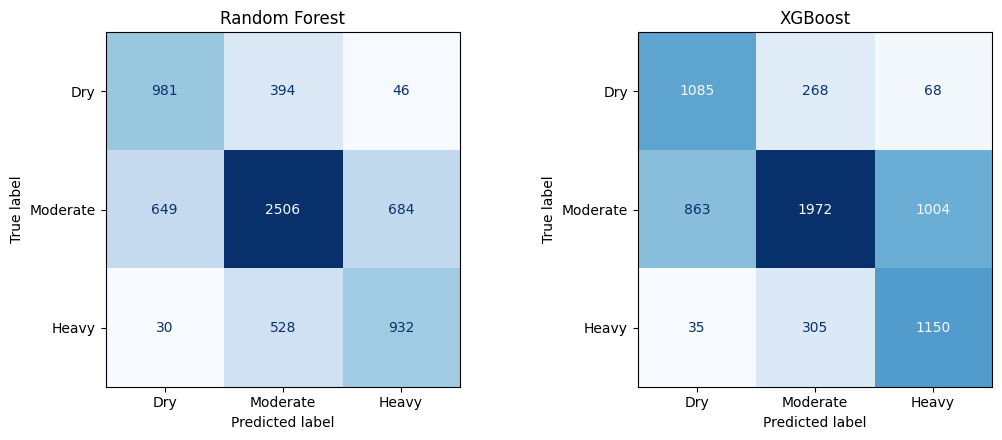

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, name in [(axes[0], rf_pred, "Random Forest"), (axes[1], xgb_pred, "XGBoost")]:
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=CLASS_NAMES).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

**How to read the confusion matrix:** rows = real class, columns = predicted class.
The diagonal shows correct predictions. Most errors are between **neighbouring** classes
(Dry ↔ Moderate, Moderate ↔ Heavy). Dry ↔ Heavy mistakes are rare, which is a good sign.

### 4.1 Which features matter most?

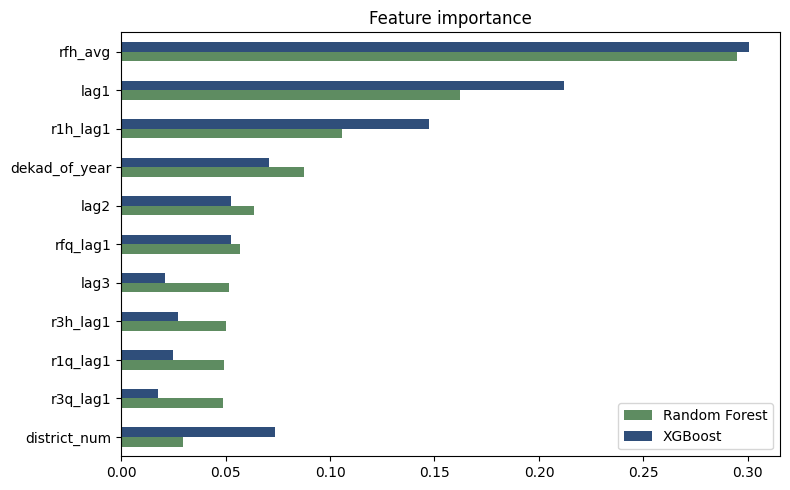

,Random Forest,XGBoost
rfh_avg,0.295,0.300
lag1,0.162,0.212
r1h_lag1,0.106,0.147
dekad_of_year,0.088,0.071
lag2,0.064,0.053
rfq_lag1,0.057,0.052
lag3,0.052,0.021
r3h_lag1,0.050,0.027
r1q_lag1,0.049,0.025
r3q_lag1,0.049,0.017


In [20]:
imp = pd.DataFrame({"Random Forest": rf_model.feature_importances_,
                    "XGBoost": xgb_model.feature_importances_}, index=FEATURES)
imp = imp / imp.sum()          # make both sum to 1, so they can be compared
imp.sort_values("Random Forest").plot(kind="barh", figsize=(8, 5),
                                      color=["#5E8C61", "#2F4E7A"])
plt.title("Feature importance"); plt.tight_layout(); plt.show()
imp.sort_values("Random Forest", ascending=False).round(3)

### 4.2 Results by district (macro F1)

In [21]:
by_d = []
for code_, part in test.groupby("PCODE"):
    idx = part.index - test.index[0]
    by_d.append({"District": DISTRICTS[code_],
                 "RF": f1_score(part["label"], rf_pred[idx], average="macro"),
                 "XGB": f1_score(part["label"], xgb_pred[idx], average="macro")})
pd.DataFrame(by_d).sort_values("RF", ascending=False).round(3).reset_index(drop=True)

,District,RF,XGB
0,Mullaitivu,0.651,0.628
1,Kilinochchi,0.646,0.625
2,Jaffna,0.643,0.623
3,Mannar,0.617,0.619
4,Vavuniya,0.606,0.580
5,Anuradhapura,0.606,0.600
6,Puttalam,0.601,0.576
7,Polonnaruwa,0.596,0.572
8,Trincomalee,0.595,0.577
9,Kurunegala,0.591,0.593


## 5. Save the models and app data (pickle files)
We save the models with **pickle** (compressed with gzip, because the Random Forest file is large).
The app (backend) loads these files, so it does not need to train again.
`artifacts.pkl` stores what the app needs: the normal rainfall tables, metrics,
confusion matrices, feature importance, and some real test rows for examples.

In [22]:
import os, gzip
os.makedirs("models", exist_ok=True)

# The Random Forest pickle is large (many deep trees), so we compress the
# pickle files with gzip. They are still normal pickle files inside.
with gzip.open("models/rf_model.pkl.gz", "wb") as f:
    pickle.dump(rf_model, f)
with gzip.open("models/xgb_model.pkl.gz", "wb") as f:
    pickle.dump(xgb_model, f)

# Normal (long-term average) values for each district + dekad
normals = (df.groupby(["PCODE", "dekad_of_year"])[["rfh_avg", "r1h_avg", "r3h_avg"]]
             .first().apply(tuple, axis=1).to_dict())

examples = test[["PCODE", "date", "dekad_of_year", "lag1", "lag2", "lag3",
                 "r3h_lag1", "rfh", "label"]].reset_index(drop=True)

artifacts = {
    "features": FEATURES,
    "class_names": CLASS_NAMES,
    "normals": normals,
    "metrics": results.to_dict(),
    "confusion": {"Random Forest": confusion_matrix(y_test, rf_pred).tolist(),
                  "XGBoost": confusion_matrix(y_test, xgb_pred).tolist()},
    "importance": imp.to_dict(),
    "best_params": {"Random Forest": {**rf_search.best_params_, "n_estimators": 200},
                    "XGBoost": xgb_search.best_params_},
    "train_period": (str(train["date"].min().date()), str(train["date"].max().date())),
    "test_period": (str(test["date"].min().date()), str(test["date"].max().date())),
    "n_train": len(train), "n_test": len(test),
    "examples": examples,
}
with open("models/artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

for f_ in os.listdir("models"):
    print(f_, round(os.path.getsize(f"models/{f_}") / 1e6, 2), "MB")

artifacts.pkl 0.52 MB
rf_model.pkl.gz 22.65 MB
xgb_model.pkl.gz 0.14 MB


## 6. Inference (step 4)
Load the saved models (like the backend does) and predict from **simple inputs**, the same
inputs the user types in the app.

**Check first:** we build features from simple inputs for a real test row, and compare with the
features made in step 2. They must be the same (otherwise the app would give wrong inputs to the model).

In [23]:
with gzip.open("models/rf_model.pkl.gz", "rb") as f:
    rf_loaded = pickle.load(f)
with gzip.open("models/xgb_model.pkl.gz", "rb") as f:
    xgb_loaded = pickle.load(f)

row = test.iloc[100]
x_app = build_feature_row(row["PCODE"], int(row["dekad_of_year"]),
                          row["lag1"], row["lag2"], row["lag3"], row["r3h_lag1"], normals)
x_nb = test[FEATURES].iloc[[100]].reset_index(drop=True)
print("Same features as in training?", np.allclose(x_app.values, x_nb.values, atol=1e-3))

Same features as in training? True


In [24]:
# Example: Colombo, 3rd dekad of May (dekad 15), after a wet period
x = build_feature_row("LK11", 15, rain_t1=213.4, rain_t2=86.5, rain_t3=106.9,
                      rain_3months=620.0, normals=normals)
for name, m in [("Random Forest", rf_loaded), ("XGBoost", xgb_loaded)]:
    p = m.predict_proba(x)[0]
    print(f"{name:14s} -> {CLASS_NAMES[p.argmax()]:9s}",
          {c: f"{v:.0%}" for c, v in zip(CLASS_NAMES, p)})

Random Forest  -> Heavy     {'Dry': '1%', 'Moderate': '15%', 'Heavy': '83%'}
XGBoost        -> Heavy     {'Dry': '3%', 'Moderate': '15%', 'Heavy': '82%'}


## 7. Conclusion

**1. Both models beat the simple rules on the main metric (macro F1).**
The *normal rainfall rule* has a slightly higher **accuracy**, because it is very good at the
large "Moderate" class. But it misses many **Dry** and **Heavy** dekads (low macro recall).
The ML models find many more of these, which are the dekads that matter most
(drought and flood planning). This is the effect of the **class weights**: we accept a small loss
in accuracy to catch the important minority classes.

**2. RF vs XGBoost**
- In cross-validation (1981–2018), XGBoost scored higher.
- On the unseen test years (2019–2026), **Random Forest has the higher macro F1 and accuracy**.
- **XGBoost has the higher recall** for Dry and Heavy, but lower precision: it predicts the
  extreme classes more often (more false alarms).
- So the "best" model depends on the use: to **not miss** floods or droughts, XGBoost;
  for **fewer false alarms** and better overall balance, Random Forest.
- The change between CV and test results suggests that the rainfall pattern has shifted a little
  in recent years (more Heavy dekads in the test years: 22% vs 18% in training).

**3. Important features:** the normal rainfall for the time of year (`rfh_avg`) and the recent
rainfall (`lag1`, last month total) are the strongest signals.

**4. Districts:** results are better in the dry zone (north) and weaker in the wet zone
(south-west, e.g. Galle, Kalutara, Ratnapura), where rain changes more from dekad to dekad.

**5. Limitations and next steps:** only past rainfall is used. Weather forecasts (wind, sea
temperature, cyclones) are not in the data. Adding CHIRPS-GEFS forecasts or monsoon / ENSO indices
could improve the results.